<a href="https://colab.research.google.com/github/EricChen356/video-background-remover/blob/main/SAM3_Video_Background_Remover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SAM 3 Video Background Remover  ·  green-screen / alpha / transparent

SAM 3 -> MatAnyone2 pipeline


Keeps the **foreground subject(s)** and replaces the background with a green screen,
holding up on **fine hair edges** and staying **temporally stable** across scene cuts.

**Pipeline (per video):**
1. **Probe** metadata (fps, frames, resolution, audio).
2. **Scene-cut detection** with **PySceneDetect** (`AdaptiveDetector` + `ThresholdDetector` for fades).
3. **Per shot** (fresh SAM3 session so tracking memory never smears across a cut):
   - **SAM 3** (HF `transformers`, *text* prompt `"person"`) → per-frame instance masks + stable `object_id`s.
   - **Foreground selection** via **Depth Anything V2** (median depth inside each mask) + geometry tie-breakers.
   - **MatAnyone** mask-guided matting, seeded from the coarse mask → soft alpha with hair detail.
     Re-seeded when a new subject becomes foreground mid-shot.
4. **Composite** in float: `out = fg*alpha + green*(1-alpha)`.
5. **Reassemble** at original fps, **mux audio**, write atomically, resume-skip.

> Verified against the docs before coding: SAM3 video uses **text prompts only** (no boxes);
> `facebook/sam3.1` is weights-only with no `transformers` integration, so the transformers path
> uses `facebook/sam3`. Depth Anything V2 outputs **relative inverse depth** (larger = nearer).

In [ ]:
#  ──── INSTALL DEPENDENCIES ──────────────────────────────────────────────────────────────────────
import os
from google.colab import userdata
!git clone https://github.com/pq-yang/MatAnyone2.git
%cd MatAnyone2
!pip install -e . -q

!pip install git+https://github.com/facebookresearch/sam3.git -q

!pip install ultralytics -q

!pip install torch torchvision -q

!pip install "imageio>=2.33,!=2.35.0" "huggingface-hub>=1.5.0,<2.0" -q

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

print('\n✅ All dependencies installed.')


In [ ]:
#  ──── INSTALL MODEL WEIGHTS ────────────────────────────────────────────────
import os, requests, tqdm

MA2_PATH = 'pretrained_models/matanyone2.pth'
MA2_URL  = 'https://github.com/pq-yang/MatAnyone2/releases/download/v1.0.0/matanyone2.pth'

if os.path.exists(MA2_PATH):
    os.remove(MA2_PATH)
    print('Removed corrupt checkpoint')

os.makedirs('pretrained_models', exist_ok=True)

response = requests.get(MA2_URL, stream=True)
total = int(response.headers.get('content-length', 0))

with open(MA2_PATH, 'wb') as f, tqdm.tqdm(
    desc='matanyone2.pth',
    total=total,
    unit='B',
    unit_scale=True,
    unit_divisor=1024,
) as bar:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)
        bar.update(len(chunk))

print(f'Downloaded: {os.path.getsize(MA2_PATH) / 1e6:.1f} MB')

In [ ]:
# ──── USER CONFIG ────────────────────────────────────────────────────────────────────────
# Everything you normally tune lives here. Defaults are conservative and work well
# for typical single/multi-person footage — change values, not the cells below.
import os as _os
import numpy as np

# ── Paths ─────────────────────────────────────────────────────────────────────
INPUT_DIR   = '/content/videos'           # folder of input videos (processed as a batch)
OUTPUT_DIR  = '/content/matanyone2_out'   # mattes / alpha / debug masks are written here

# ── Output ────────────────────────────────────────────────────────────────────
OUTPUT_MODE = 'greenscreen'   # 'greenscreen' | 'alpha' | 'transparent'
GREEN       = np.array([120, 255, 152], dtype=np.float32) / 255.0   # key colour for greenscreen

# ── Performance ───────────────────────────────────────────────────────────────
# MAX_SIZE: if >0, run matting at this min-side resolution then upscale the alpha
#           back to full res (big speedup on 4K; edges stay sharp). 0 = full res.
MAX_SIZE    = 0

# -- Encoding (video writer) ---------------------------------------------------
# WRITE_ALPHA_VIDEO: also write the standalone <name>_alpha.mp4 matte. Turn OFF
#                    to skip a whole second encode (~halves the encode step).
# ENCODER_PRESET   : x264 speed/size trade-off -- ultrafast, veryfast, fast, medium.
#                    A faster preset = much quicker encode, marginally larger file.
# ENCODER_CRF      : quality, lower = better/larger (~18 is visually lossless).
WRITE_ALPHA_VIDEO = True
ENCODER_PRESET    = 'veryfast'
ENCODER_CRF       = 18

# ── Matting quality (MatAnyone 2) ─────────────────────────────────────────────
# Warmup uses a two-phase strategy to stabilise the matte from frame 0:
#   Phase 1 (static): N_WARMUP_STATIC copies of the first frame fed with the seed
#                     mask to plant the foreground identity into recurrent memory.
#   Phase 2 (motion): the first N_WARMUP_MOTION real frames run without saving
#                     output, so the model sees actual motion before results begin.
# Increase either value if the first few seconds of output are still unstable.
#
# R_DILATE : grow the SAM 3 seed mask by N px before matting, giving MatAnyone
#            head-room to recover hair / soft edges (the matter pulls the edge back in).
# R_ERODE  : shrink the seed mask by N px. Keep at 0 so we never clip into the
#            subject; only raise it if the seed mask visibly leaks into background.
N_WARMUP_STATIC = 20
N_WARMUP_MOTION = 20
R_ERODE     = 0
R_DILATE    = 30

# ── Detection thresholds ──────────────────────────────────────────────────────
YOLO_CONF     = 0.2   # person-detection confidence floor
CUT_THRESHOLD = 0.30   # scene-cut sensitivity (lower = more cuts)

# ── Troubleshooting ───────────────────────────────────────────────────────────
# Save the raw SAM 3 seed mask + a red overlay for every shot, so you can inspect
# what the matter was initialised with *before* MatAnyone 2 runs.
SAVE_SEED_MASKS = True

VIDEO_EXTENSIONS = ('*.mp4', '*.mov', '*.avi', '*.mkv')

_os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Config loaded.')

In [ ]:
import torch
import numpy as np
import cv2
from PIL import Image

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# TF32 matmuls on Ampere+ GPUs — a near-free speedup with no visible quality change.
if torch.cuda.is_available() and torch.cuda.get_device_properties(0).major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# ── MatAnyone 2 (video matting) ───────────────────────────────────────────────
# Loaded and kept in float32 — do NOT wrap in global bfloat16 autocast, as that
# degrades matting quality for borderline pixels (fine hair, held objects, etc.).
from hydra.core.global_hydra import GlobalHydra
from matanyone2.utils.get_default_model import get_matanyone2_model

GlobalHydra.instance().clear()
matanyone2_model = get_matanyone2_model(MA2_PATH, device)
matanyone2_model = matanyone2_model.float()
print('✅ MatAnyone 2 loaded')

# ── SAM 3 image predictor (box / text → pixel-precise mask) ───────────────────
# SAM 3 weights are bfloat16; autocast is applied locally around each SAM 3 call
# in get_foreground_mask() to avoid dtype mismatches, without affecting MatAnyone2.
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

sam3_model = build_sam3_image_model(device=device, eval_mode=True)
sam3_predictor = Sam3Processor(sam3_model, device=device)
print('✅ SAM 3 loaded')

# ── YOLOv8n (person detector → seed boxes for SAM 3) ──────────────────────────
from ultralytics import YOLO
yolo_model = YOLO('yolov8n.pt')
print('✅ YOLOv8n loaded')

In [ ]:
import time
import torch.nn.functional as F
import imageio
from tqdm import tqdm
from contextlib import contextmanager, nullcontext
from collections import OrderedDict
from matanyone2.inference.inference_core import InferenceCore
from matanyone2.utils.inference_utils import gen_dilate, gen_erosion

# ─────────────────────────────────────────────────────────────────────────────
#  STEP 0 — STEP TIMER
# ─────────────────────────────────────────────────────────────────────────────
class StepTimer:
    ORDER = ['decode', 'scene_cut', 'yolo', 'sam', 'mask_debug',
             'matting_pre', 'matting_warmup', 'matting_infer', 'matting_post',
             'composite', 'encode']

    def __init__(self, sync_cuda: bool = True):
        self.totals = OrderedDict()
        self.counts = OrderedDict()
        self.sync_cuda = bool(sync_cuda) and torch.cuda.is_available()

    @contextmanager
    def track(self, name: str):
        if self.sync_cuda:
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        try:
            yield
        finally:
            if self.sync_cuda:
                torch.cuda.synchronize()
            dt = time.perf_counter() - t0
            self.totals[name] = self.totals.get(name, 0.0) + dt
            self.counts[name] = self.counts.get(name, 0) + 1

    def merge(self, other: 'StepTimer'):
        for k, v in other.totals.items():
            self.totals[k] = self.totals.get(k, 0.0) + v
            self.counts[k] = self.counts.get(k, 0) + other.counts[k]

    def report(self, title: str = 'Timing breakdown', n_frames: int | None = None):
        keys  = [k for k in self.ORDER if k in self.totals]
        keys += [k for k in self.totals if k not in self.ORDER]
        total = sum(self.totals.values())
        print(f'\n{"─" * 70}')
        print(f'⏱  {title}' + (f'   ({n_frames} output frames)' if n_frames else ''))
        print(f'{"─" * 70}')
        print(f'   {"step":<16}{"time":>10}{"share":>9}{"calls":>8}{"ms/call":>11}')
        for k in keys:
            t, c = self.totals[k], self.counts[k]
            pct  = 100 * t / total if total else 0.0
            print(f'   {k:<16}{t:>9.2f}s{pct:>8.1f}%{c:>8}{1000 * t / c:>10.1f}')
        print(f'   {"·" * 60}')
        line = f'   {"TOTAL":<16}{total:>9.2f}s{100.0:>8.1f}%'
        if n_frames:
            line += f'{n_frames:>8}{1000 * total / n_frames:>10.1f}  (/out frame)'
        print(line)
        print(f'{"─" * 70}')


def _track(timer: 'StepTimer | None', name: str):
    return timer.track(name) if timer is not None else nullcontext()

# ─────────────────────────────────────────────────────────────────────────────
#  STEP 2 — SCENE-CUT DETECTION
# ─────────────────────────────────────────────────────────────────────────────
def compute_scene_cuts(frames_bgr: list[np.ndarray],
                       threshold: float = 0.30) -> tuple[list[int], list[float]]:
    boundaries = [0]
    scores: list[float] = []
    prev_hist = None
    for idx, frame in enumerate(frames_bgr):
        hsv  = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        hist = [cv2.calcHist([hsv], [c], None, [64], [0, 256]) for c in range(3)]
        for h in hist:
            cv2.normalize(h, h)
        if prev_hist is not None:
            diffs = [cv2.compareHist(prev_hist[c], hist[c], cv2.HISTCMP_BHATTACHARYYA)
                     for c in range(3)]
            score = float(np.mean(diffs))
            scores.append(score)
            if score > threshold:
                boundaries.append(idx)
        prev_hist = hist
    return boundaries, scores

# ─────────────────────────────────────────────────────────────────────────────
#  STEP 3 — AUTO FOREGROUND MASK
# ─────────────────────────────────────────────────────────────────────────────
def get_foreground_mask(frame_bgr: np.ndarray, yolo_conf: float = 0.4,
                        timer: 'StepTimer | None' = None) -> np.ndarray | None:
    h, w = frame_bgr.shape[:2]
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    with _track(timer, 'yolo'):
        yolo_results = yolo_model(frame_rgb, conf=yolo_conf, classes=[0], verbose=False)[0]

    boxes_xyxy = []
    if yolo_results.boxes is not None and len(yolo_results.boxes) > 0:
        raw_boxes = yolo_results.boxes.xyxy.cpu().numpy()
        confs     = yolo_results.boxes.conf.cpu().numpy()
        scored = []
        cx_frame, cy_frame = w / 2, h / 2
        for box, conf in zip(raw_boxes, confs):
            x1, y1, x2, y2 = box
            bw, bh = x2 - x1, y2 - y1
            cx_box, cy_box = (x1 + x2) / 2, (y1 + y2) / 2
            centrality = 1.0 - (abs(cx_box - cx_frame) / cx_frame * 0.5 +
                                abs(cy_box - cy_frame) / cy_frame * 0.5)
            area_frac = (bw * bh) / (w * h)
            score = float(conf) * (1 + centrality) * (1 + area_frac * 3)
            scored.append((score, box))
        best_score = max(s for s, _ in scored)
        boxes_xyxy = [b for s, b in scored if s >= 0.3 * best_score]

    # SAM 3 weights are bfloat16 — autocast is scoped locally here only,
    # so MatAnyone2 (which runs in float32) is not affected.
    with _track(timer, 'sam'), torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        state = sam3_predictor.set_image(Image.fromarray(frame_rgb))

        if boxes_xyxy:
            combined_mask = np.zeros((h, w), dtype=np.uint8)
            for box in boxes_xyxy:
                x1, y1, x2, y2 = (float(v) for v in box)
                box_norm = [((x1 + x2) / 2) / w, ((y1 + y2) / 2) / h,
                            (x2 - x1) / w, (y2 - y1) / h]
                sam3_predictor.reset_all_prompts(state)
                out = sam3_predictor.add_geometric_prompt(box=box_norm, label=True,
                                                          state=state)
                masks_logits = out['masks_logits'].float()
                scores       = out['scores'].float()
                if masks_logits is not None and masks_logits.numel() > 0:
                    best_idx = int(torch.argmax(scores))
                    best = ((masks_logits[best_idx, 0] > 0.5)
                            .cpu().numpy().astype(np.uint8)) * 255
                    combined_mask = cv2.bitwise_or(combined_mask, best)
            return (combined_mask if combined_mask.any() else None), boxes_xyxy

        print('  [WARN] No person detected by YOLO — using SAM 3 text-prompt fallback')
        sam3_predictor.reset_all_prompts(state)
        out = sam3_predictor.set_text_prompt(prompt='person', state=state)
        masks_logits = out['masks_logits'].float()
        scores       = out['scores'].float()
        if masks_logits is None or masks_logits.numel() == 0:
            return None, []
        combined_mask = np.zeros((h, w), dtype=np.uint8)
        for mi in range(len(masks_logits)):
            m = ((masks_logits[mi, 0] > 0.5)
                 .cpu().numpy().astype(np.uint8)) * 255
            combined_mask = cv2.bitwise_or(combined_mask, m)
        return (combined_mask if combined_mask.any() else None), []

# ─────────────────────────────────────────────────────────────────────────────
#  Small reusable helpers
# ─────────────────────────────────────────────────────────────────────────────
def make_seed_overlay(frame_bgr: np.ndarray, mask: np.ndarray, alpha: float = 0.45,
                      boxes: list | None = None, box_color=(255, 220, 0),
                      box_thickness: int = 2) -> np.ndarray:
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    m   = mask > 127
    rgb[m] = rgb[m] * (1 - alpha) + np.array([255, 40, 40], np.float32) * alpha
    out = np.clip(rgb, 0, 255).astype(np.uint8)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(out, contours, -1, (255, 255, 255), 2)
    if boxes:
        for box in boxes:
            x1, y1, x2, y2 = (int(round(v)) for v in box)
            cv2.rectangle(out, (x1, y1), (x2, y2), box_color, box_thickness)
    return out


def composite_result(pha_u8: np.ndarray, fgr_u8: np.ndarray,
                     mode: str, green: np.ndarray) -> np.ndarray:
    pha = pha_u8 / 255.
    fgr = fgr_u8 / 255.
    if mode == 'greenscreen':
        comp = fgr + green * (1.0 - pha)
    elif mode == 'alpha':
        comp = np.repeat(pha, 3, axis=2)
    else:
        comp = fgr
    return np.round(np.clip(comp * 255, 0, 255)).astype(np.uint8)


def thumbnail(img: np.ndarray, max_w: int = 640) -> np.ndarray:
    h, w = img.shape[:2]
    if w <= max_w:
        return img
    return cv2.resize(img, (max_w, int(h * max_w / w)), interpolation=cv2.INTER_AREA)

# ─────────────────────────────────────────────────────────────────────────────
#  STEP 4 — MATANYONE 2 SHOT PROCESSOR
#
#  Two-phase warmup strategy:
#    Phase 1 (static)  — n_warmup_static copies of the first frame, fed with the
#                        seed mask. Plants the foreground identity into the model's
#                        recurrent memory without any motion.
#    Phase 2 (motion)  — the first n_warmup_motion real frames run without saving
#                        output. The model sees actual subject motion so its memory
#                        is ready for frame 0 of real output.
#  Real output is then collected from frame 0 onward.
# ─────────────────────────────────────────────────────────────────────────────
def run_matanyone2_on_shot(
    frames_bgr: list[np.ndarray],
    first_frame_mask: np.ndarray,
    n_warmup_static: int = 20,
    n_warmup_motion: int = 20,
    r_erode: int = 0,
    r_dilate: int = 20,
    timer: 'StepTimer | None' = None,
) -> list[dict]:
    with _track(timer, 'matting_pre'):
        processor = InferenceCore(matanyone2_model, cfg=matanyone2_model.cfg)

        vframes = torch.stack([
            torch.from_numpy(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)).permute(2, 0, 1)
            for f in frames_bgr
        ])  # uint8 [T, C, H, W]

        h_orig, w_orig = vframes.shape[-2:]
        resized = False
        if MAX_SIZE > 0 and min(h_orig, w_orig) > MAX_SIZE:
            scale = MAX_SIZE / min(h_orig, w_orig)
            new_h, new_w = int(h_orig * scale), int(w_orig * scale)
            vframes = (F.interpolate(vframes.float(), size=(new_h, new_w), mode='area')
                       .round().clamp_(0, 255).to(torch.uint8))
            resized = True
        h, w = vframes.shape[-2:]

        # Phase 1: static warmup (repeated first frame)
        warmup_static = vframes[0:1].repeat(n_warmup_static, 1, 1, 1)
        # Phase 2: motion warmup (first real frames, capped by shot length)
        n_motion_actual = min(n_warmup_motion, len(frames_bgr))
        warmup_motion = vframes[:n_motion_actual]

        # Full sequence: [static warmup | motion warmup | real frames]
        vframes_full = torch.cat([warmup_static, warmup_motion, vframes], dim=0)
        total_warmup = n_warmup_static + n_motion_actual
        total_len    = len(vframes_full)

        mask_np = first_frame_mask.copy()
        if r_dilate > 0:
            mask_np = gen_dilate(mask_np, r_dilate, r_dilate)
        if r_erode > 0:
            mask_np = gen_erosion(mask_np, r_erode, r_erode)

        mask_t = torch.from_numpy(mask_np).float().to(device)
        if resized:
            mask_t = F.interpolate(mask_t.unsqueeze(0).unsqueeze(0),
                                   size=(h, w), mode='nearest')[0, 0]

    objects = [1]
    results = []

    with torch.inference_mode():
        for ti in range(total_len):
            is_static_warmup = ti < n_warmup_static
            is_warmup        = ti < total_warmup
            step_name = 'matting_warmup' if is_warmup else 'matting_infer'

            with _track(timer, step_name):
                image = (vframes_full[ti].float() / 255.).to(device)

                if ti == 0:
                    # Seed the model with the foreground mask on the first frame.
                    out_prob = processor.step(image, mask_t, objects=objects)
                    out_prob = processor.step(image, first_frame_pred=True)
                elif is_static_warmup:
                    # Reinforce the mask on subsequent static frames.
                    out_prob = processor.step(image, first_frame_pred=True)
                else:
                    # Motion warmup and real frames: free tracking, no mask override.
                    out_prob = processor.step(image)

                alpha_t = processor.output_prob_to_mask(out_prob)

            # Save only real frames (after both warmup phases).
            if not is_warmup:
                with _track(timer, 'matting_post'):
                    image_np = vframes_full[ti].permute(1, 2, 0).numpy()       # uint8 HWC
                    pha_np   = alpha_t.unsqueeze(2).cpu().float().numpy()      # float [H,W,1]
                    fgr_np   = (image_np / 255.) * pha_np

                    pha_out = np.round(np.clip(pha_np * 255, 0, 255)).astype(np.uint8)
                    fgr_out = np.round(np.clip(fgr_np * 255, 0, 255)).astype(np.uint8)

                    if resized:
                        pha_out = cv2.resize(pha_out[..., 0], (w_orig, h_orig),
                                             interpolation=cv2.INTER_LINEAR)[..., None]
                        fgr_out = cv2.resize(fgr_out, (w_orig, h_orig),
                                             interpolation=cv2.INTER_LINEAR)

                    results.append({'pha': pha_out, 'fgr': fgr_out})

    return results


print('✅ Pipeline functions defined')

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
#  FULL PIPELINE  (batch over every video in INPUT_DIR)
# ─────────────────────────────────────────────────────────────────────────────
import gc, glob

all_videos = []
for ext in VIDEO_EXTENSIONS:
    all_videos.extend(glob.glob(os.path.join(INPUT_DIR, ext)))
all_videos = sorted(all_videos)
print(f'Found {len(all_videos)} video(s) to process')

grand_timer   = StepTimer()
grand_frames  = 0
preview_shots = []
last_results  = []

for video_idx, INPUT_VIDEO in enumerate(all_videos):
    base_name   = os.path.splitext(os.path.basename(INPUT_VIDEO))[0]
    output_path = os.path.join(OUTPUT_DIR, f'{base_name}_matte.mp4')
    alpha_path  = os.path.join(OUTPUT_DIR, f'{base_name}_alpha.mp4')
    seed_dir    = os.path.join(OUTPUT_DIR, f'{base_name}_seed_masks')

    if os.path.exists(output_path) and os.path.getsize(output_path) > 0:
        print(f'\n[{video_idx+1}/{len(all_videos)}] Skipping (already done): {base_name}')
        continue

    print(f'\n{"="*70}\n[{video_idx+1}/{len(all_videos)}] Processing: {base_name}\n{"="*70}')
    timer = StepTimer()
    preview_shots = []

    try:
        cap = cv2.VideoCapture(INPUT_VIDEO)
        fps    = cap.get(cv2.CAP_PROP_FPS)
        total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap.release()
        print(f'Video: {total} frames @ {fps:.2f}fps  |  {width}×{height}')

        print('\n[1/5] Decoding frames ...')
        with timer.track('decode'):
            cap = cv2.VideoCapture(INPUT_VIDEO)
            all_frames = []
            pbar = tqdm(total=total if total > 0 else None, desc='Decoding')
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                all_frames.append(frame)
                pbar.update(1)
            pbar.close()
            cap.release()
        total = len(all_frames)
        print(f'Decoded {total} frames')

        print('\n[2/5] Detecting scene cuts ...')
        with timer.track('scene_cut'):
            cut_starts, _ = compute_scene_cuts(all_frames, threshold=CUT_THRESHOLD)
        shot_intervals = [
            (s, cut_starts[i + 1] if i + 1 < len(cut_starts) else total)
            for i, s in enumerate(cut_starts)
        ]
        print(f'Found {len(shot_intervals)} shot(s): {shot_intervals}')

        print('\n[3/5] Segmenting + matting shots ...')
        if SAVE_SEED_MASKS:
            os.makedirs(seed_dir, exist_ok=True)
        all_results = []

        for shot_idx, (shot_start, shot_end) in enumerate(shot_intervals):
            shot_frames = all_frames[shot_start:shot_end]
            n_frames    = len(shot_frames)
            print(f'\n  Shot {shot_idx+1}/{len(shot_intervals)}: '
                  f'frames {shot_start}–{shot_end-1} ({n_frames} frames)')
            if n_frames == 0:
                continue

            first_frame_mask, yolo_boxes = get_foreground_mask(
                shot_frames[0], yolo_conf=YOLO_CONF, timer=timer)

            if first_frame_mask is None:
                print(f'  [WARN] No foreground found — writing blank alpha for shot {shot_idx+1}.')
                h, w = shot_frames[0].shape[:2]
                all_results.extend({'pha': np.zeros((h, w, 1), np.uint8),
                                    'fgr': np.zeros((h, w, 3), np.uint8)} for _ in shot_frames)
                continue

            with timer.track('mask_debug'):
                overlay = make_seed_overlay(shot_frames[0], first_frame_mask, boxes=yolo_boxes)
                if SAVE_SEED_MASKS:
                    cv2.imwrite(os.path.join(seed_dir, f'shot_{shot_idx+1:02d}_mask.png'),
                                first_frame_mask)
                    cv2.imwrite(os.path.join(seed_dir, f'shot_{shot_idx+1:02d}_overlay.png'),
                                cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

            shot_results = run_matanyone2_on_shot(
                shot_frames, first_frame_mask,
                n_warmup_static=N_WARMUP_STATIC, n_warmup_motion=N_WARMUP_MOTION,
                r_erode=R_ERODE, r_dilate=R_DILATE, timer=timer)
            all_results.extend(shot_results)

            matted0 = composite_result(shot_results[0]['pha'], shot_results[0]['fgr'],
                                       'greenscreen', GREEN)
            preview_shots.append({'start': shot_start, 'end': shot_end,
                                  'overlay': thumbnail(overlay), 'matted': thumbnail(matted0),
                                  'n_boxes': len(yolo_boxes)})

            torch.cuda.empty_cache(); gc.collect()

        print(f'\nProcessed {len(all_results)} output frames total')

        print('\n[4/5] Compositing ...')
        composite_frames, alpha_frames = [], []
        with timer.track('composite'):
            for r in tqdm(all_results, desc='Compositing'):
                composite_frames.append(composite_result(r['pha'], r['fgr'], OUTPUT_MODE, GREEN))
                alpha_frames.append(r['pha'])

        print('\n[5/5] Encoding ...')
        enc = dict(codec='libx264', fps=fps,
                   output_params=['-preset', ENCODER_PRESET, '-crf', str(ENCODER_CRF)])
        tmp_output, tmp_alpha = output_path + '.tmp.mp4', alpha_path + '.tmp.mp4'
        with timer.track('encode'):
            imageio.mimwrite(tmp_output, composite_frames, **enc)
            os.rename(tmp_output, output_path)

            if WRITE_ALPHA_VIDEO:
                imageio.mimwrite(tmp_alpha, [a[..., 0] for a in alpha_frames], **enc)
                os.rename(tmp_alpha, alpha_path)

            if OUTPUT_MODE == 'transparent':
                rgba_dir = os.path.join(OUTPUT_DIR, f'{base_name}_rgba_frames')
                os.makedirs(rgba_dir, exist_ok=True)
                for fi, (rgb, a) in enumerate(zip(composite_frames, alpha_frames)):
                    Image.fromarray(np.concatenate([rgb, a], axis=2)).save(
                        os.path.join(rgba_dir, f'{fi:05d}.png'))
                print(f'RGBA frames saved to {rgba_dir}')

        print(f'\n✅ Done: {base_name}')
        print(f'   Composite : {output_path}')
        if WRITE_ALPHA_VIDEO:
            print(f'   Alpha     : {alpha_path}')
        if SAVE_SEED_MASKS:
            print(f'   Seed masks: {seed_dir}')

        n_out = len(all_results)
        timer.report(title=base_name, n_frames=n_out)
        grand_timer.merge(timer); grand_frames += n_out

        last_results = all_results
        last_shot_intervals = shot_intervals

        del all_frames, composite_frames, alpha_frames
        torch.cuda.empty_cache(); gc.collect()

    except Exception as e:
        print(f'\n❌ FAILED: {base_name} — {e}\n   Continuing to next video ...')
        for tmp in [output_path + '.tmp.mp4', alpha_path + '.tmp.mp4']:
            if os.path.exists(tmp):
                os.remove(tmp)
        torch.cuda.empty_cache(); gc.collect()
        continue

print(f'\n{"="*70}\nAll videos processed.')

if grand_timer.totals:
    grand_timer.report(title='ALL VIDEOS — grand total', n_frames=grand_frames)

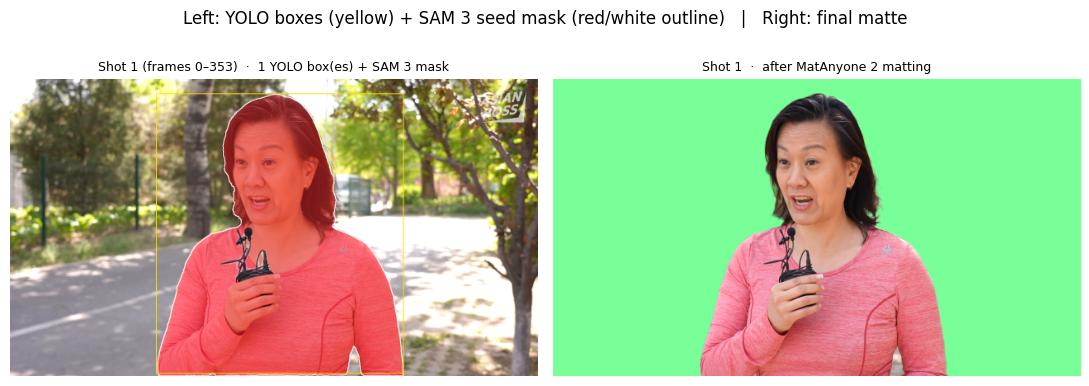

Shot preview saved -> /content/matanyone2_out/shot_preview.png


In [59]:
import matplotlib.pyplot as plt

if not preview_shots:
    print('No shots to preview (run the pipeline cell first).')
else:
    n = len(preview_shots)
    fig, axes = plt.subplots(n, 2, figsize=(11, 4.2 * n))
    axes = np.array(axes).reshape(n, 2)
    for i, sh in enumerate(preview_shots):
        axes[i, 0].imshow(sh['overlay'])
        axes[i, 0].set_title(
            f"Shot {i+1} (frames {sh['start']}–{sh['end']-1})  ·  "
            f"{sh.get('n_boxes', 0)} YOLO box(es) + SAM 3 mask",
            fontsize=9)
        axes[i, 1].imshow(sh['matted'])
        axes[i, 1].set_title(f"Shot {i+1}  ·  after MatAnyone 2 matting", fontsize=9)
        axes[i, 0].axis('off'); axes[i, 1].axis('off')

    plt.suptitle('Left: YOLO boxes (yellow) + SAM 3 seed mask (red/white outline)   |   Right: final matte',
                 fontsize=12)
    plt.tight_layout()
    out_png = os.path.join(OUTPUT_DIR, 'shot_preview.png')
    plt.savefig(out_png, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Shot preview saved -> {out_png}')

In [ ]:
from google.colab import files

print(f'Downloading: {output_path}')
files.download(output_path)

In [ ]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(INPUT_VIDEO)
scores = []
prev_hist = None

while True:
    ret, frame = cap.read()
    if not ret:
        break
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    hist = [cv2.calcHist([hsv], [c], None, [64], [0, 256]) for c in range(3)]
    for h in hist:
        cv2.normalize(h, h)
    if prev_hist is not None:
        diffs = [cv2.compareHist(prev_hist[c], hist[c], cv2.HISTCMP_BHATTACHARYYA) for c in range(3)]
        scores.append(float(np.mean(diffs)))
    prev_hist = hist
cap.release()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(scores, linewidth=0.8, color='steelblue', label='HSV histogram diff')
ax.axhline(CUT_THRESHOLD, color='crimson', linestyle='--', linewidth=1.2,
           label=f'Current threshold ({CUT_THRESHOLD})')
ax.set_xlabel('Frame')
ax.set_ylabel('Bhattacharyya distance')
ax.set_title('Scene cut signal — peaks above the red line are detected as cuts')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Detected cut frames at threshold {CUT_THRESHOLD}: {detect_scene_cuts(INPUT_VIDEO, CUT_THRESHOLD)}')